# Problema del Carguero - Optimización de Contenedores

## Descripción del problema

Un armador tiene un carguero con capacidad de hasta 700 toneladas. El carguero transporta contenedores de diferentes pesos para una determinada ruta. En la ruta actual el carguero puede transportar algunos de los siguientes contenedores:

| Contenedor | c1 | c2 | c3 | c4 | c5 | c6 | c7 | c8 | c9 | c10 |
|------------|----|----|----|----|----|----|----|----|----|----- |
| Peso [ton] | 100 | 155 | 50 | 112 | 70 | 80 | 60 | 118 | 110 | 55 |
| Beneficio [$/ton] | 1741 | 1622 | 1016 | 1264 | 1305 | 1389 | 1797 | 1330 | 1559 | 1578 |

El analista de la empresa del armador desea determinar el envío (conjunto de contenedores) que maximiza el beneficio.

## 1. Importación de librerías y configuración inicial

In [10]:
import pandas as pd
data = pd.read_excel("mochila_1.xlsx")


In [11]:
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from pyomo.environ import *
from pyomo.opt import SolverFactory

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 2. Problema 1: Caso Base

### 2.1 Definición de datos del problema

In [12]:
# Datos del problema original
contenedores = ['c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9', 'c10']
pesos = [61, 58, 92, 50, 108, 83, 93, 101, 54, 50]
beneficios_totales = [1100, 1147, 1442, 1591, 1078, 1385, 1777, 1196, 1753, 1371]


Capacidad = 800

print("Contenedores disponibles:")
for i, c in enumerate(contenedores):
    print(f"{c}: Peso = {pesos[i]} ton, Beneficio = ${beneficios_totales[i]:,}")

Contenedores disponibles:
c1: Peso = 61 ton, Beneficio = $1,100
c2: Peso = 58 ton, Beneficio = $1,147
c3: Peso = 92 ton, Beneficio = $1,442
c4: Peso = 50 ton, Beneficio = $1,591
c5: Peso = 108 ton, Beneficio = $1,078
c6: Peso = 83 ton, Beneficio = $1,385
c7: Peso = 93 ton, Beneficio = $1,777
c8: Peso = 101 ton, Beneficio = $1,196
c9: Peso = 54 ton, Beneficio = $1,753
c10: Peso = 50 ton, Beneficio = $1,371


### 2.2 Modelo Matemático de Optimización (Pyomo/GAMS)

**Formulación matemática:**

$$\max \sum_{i=1}^{n} b_i x_i$$

Sujeto a:

$$\sum_{i=1}^{n} p_i x_i \leq C$$

$$x_i \in \{0, 1\} \quad \forall i$$

Donde:
- $b_i$ = beneficio del contenedor $i$
- $p_i$ = peso del contenedor $i$  
- $C$ = capacidad del carguero (700 ton)
- $x_i$ = 1 si se selecciona el contenedor $i$, 0 en caso contrario

In [13]:
def resolver_mochila_optimo(pesos, beneficios, capacidad):
    """Resuelve el problema de la mochila usando Pyomo con solver CBC/GLPK"""
    
    inicio = time.time()
    
    # Crear modelo
    modelo = ConcreteModel()
    
    # Conjuntos
    n_items = len(pesos)
    modelo.I = RangeSet(0, n_items-1)
    
    # Variables de decisión
    modelo.x = Var(modelo.I, within=Binary)
    
    # Función objetivo
    modelo.obj = Objective(
        expr=sum(beneficios[i] * modelo.x[i] for i in modelo.I),
        sense=maximize
    )
    
    # Restricción de capacidad
    modelo.capacidad = Constraint(
        expr=sum(pesos[i] * modelo.x[i] for i in modelo.I) <= capacidad
    )
    
    # Resolver
    solver = SolverFactory('glpk')  # Puedes cambiar a 'glpk' si lo prefieres
    resultados = solver.solve(modelo, tee=False)
    
    tiempo_total = time.time() - inicio
    
    # Extraer solución
    solucion = []
    peso_total = 0
    beneficio_total = 0
    
    for i in modelo.I:
        if modelo.x[i].value > 0.5:
            solucion.append(i)
            peso_total += pesos[i]
            beneficio_total += beneficios[i]
    
    # Obtener información adicional
    iteraciones = resultados.solver.statistics.branch_and_bound.number_of_created_subproblems if hasattr(resultados.solver.statistics, 'branch_and_bound') else 1
    
    return solucion, beneficio_total, peso_total, tiempo_total, iteraciones

In [14]:
# Resolver el problema base con método exacto
sol_exacta, ben_exacto, peso_exacto, tiempo_exacto, iter_exacto = resolver_mochila_optimo(
    pesos, beneficios_totales, Capacidad
)

print("=== SOLUCIÓN ÓPTIMA (Método Exacto) ===")
print(f"Contenedores seleccionados: {[contenedores[i] for i in sol_exacta]}")
print(f"Beneficio total: ${ben_exacto:,}")
print(f"Peso total: {peso_exacto} ton")
print(f"Capacidad disponible: {Capacidad - peso_exacto} ton")
print(f"Tiempo computacional: {tiempo_exacto:.4f} segundos")
print(f"Número de iteraciones: {iter_exacto}")

=== SOLUCIÓN ÓPTIMA (Método Exacto) ===
Contenedores seleccionados: ['c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9', 'c10']
Beneficio total: $13,840
Peso total: 750 ton
Capacidad disponible: 50 ton
Tiempo computacional: 0.0118 segundos
Número de iteraciones: 0


## 2 Algoritmo Genético


#### Infactibilidad permitida

In [15]:
import random
import time

# -------------------------------------------------------------------
# PROBLEMA DE LA MOCHILA
# -------------------------------------------------------------------
pesos = [61, 58, 92, 50, 108, 83, 93, 101, 54, 50, 72, 51, 100, 108, 91, 112, 66, 58, 110, 73]
beneficios = [1100, 1147, 1442, 1591, 1078, 1385, 1777, 1196, 1753, 1371, 1517, 1675 , 1193, 1177, 1365, 1143, 1314, 1526, 1470, 1605]
capacidad = 800

N = len(pesos)

# -------------------------------------------------------------------
# PARÁMETROS GA
# -------------------------------------------------------------------
TAM_POB = 100
GENERACIONES = 50
PROB_CRUZA = 0.9
PROB_MUT = 0.1
MAX_ESTANCAMIENTO = 20  # Número de generaciones sin mejora para detener

# -------------------------------------------------------------------
# FUNCIONES
# -------------------------------------------------------------------
def crear_individuo():
    return [random.randint(0, 1) for _ in range(N)]

def evaluar(ind):
    peso_total = sum(w * x for w, x in zip(pesos, ind))
    beneficio_total = sum(v * x for v, x in zip(beneficios, ind))
    if peso_total > capacidad:
        return 0.5 * beneficio_total
    return beneficio_total

def ruleta(poblacion):
    fitness = [evaluar(ind) for ind in poblacion]
    total_fitness = sum(fitness)
    if total_fitness == 0:
        return random.choice(poblacion)
    r = random.uniform(0, total_fitness)
    acumulado = 0
    for ind, fit in zip(poblacion, fitness):
        acumulado += fit
        if acumulado >= r:
            return ind

def cruza(a, b):
    if random.random() > PROB_CRUZA:
        return a[:], b[:]
    punto = random.randint(1, N-1)
    return a[:punto] + b[punto:], b[:punto] + a[punto:]

def mutar(ind):
    for i in range(N):
        if random.random() < PROB_MUT:
            ind[i] = 1 - ind[i]
    return ind

# -------------------------------------------------------------------
# ALGORITMO GENÉTICO
# -------------------------------------------------------------------
poblacion = [crear_individuo() for _ in range(TAM_POB)]

# Para guardar estadísticas
historial = []
pasos_total = 0

inicio_total = time.time()
mejor_global = 0
contador_estancamiento = 0

for gen in range(GENERACIONES):
    gen_inicio = time.time()
    
    for _ in range(TAM_POB):
        padre = ruleta(poblacion)
        madre = ruleta(poblacion)
        hijo1, hijo2 = cruza(padre, madre)
        hijo1 = mutar(hijo1)
        hijo2 = mutar(hijo2)

        fit_h1 = evaluar(hijo1)
        fit_h2 = evaluar(hijo2)

        poblacion_con_fit = [(ind, evaluar(ind)) for ind in poblacion]
        peores = sorted(poblacion_con_fit, key=lambda x: x[1])[:2]
        (peor1, fit_p1), (peor2, fit_p2) = peores
        hijos = sorted([(hijo1, fit_h1), (hijo2, fit_h2)], key=lambda x: x[1], reverse=True)

        if hijos[0][1] > fit_p1:
            poblacion.remove(peor1)
            poblacion.append(hijos[0][0])
        if hijos[1][1] > fit_p2:
            poblacion.remove(peor2)
            poblacion.append(hijos[1][0])
        
        pasos_total += 1

    # Estadísticas por generación
    fitness_gen = [evaluar(ind) for ind in poblacion]
    mejor_fit = max(fitness_gen)
    peor_fit = min(fitness_gen)
    promedio_fit = sum(fitness_gen) / len(fitness_gen)
    tiempo_gen = time.time() - gen_inicio

    historial.append({
        'generacion': gen,
        'mejor': mejor_fit,
        'promedio': promedio_fit,
        'peor': peor_fit,
        'tiempo': tiempo_gen
    })

    print(f"Gen {gen}: Mejor={mejor_fit}, Promedio={promedio_fit:.2f}, Peor={peor_fit}, Tiempo={tiempo_gen:.3f}s")

    # Verificar estancamiento
    if mejor_fit > mejor_global:
        mejor_global = mejor_fit
        contador_estancamiento = 0
    else:
        contador_estancamiento += 1

    if contador_estancamiento >= MAX_ESTANCAMIENTO:
        print(f"\nNo hubo mejora en {MAX_ESTANCAMIENTO} generaciones, deteniendo algoritmo.")
        break

# -------------------------------------------------------------------
# SOLUCIÓN FINAL
# -------------------------------------------------------------------
mejor = max(poblacion, key=evaluar)
peso_final = sum(w * x for w, x in zip(pesos, mejor))
beneficio_final = evaluar(mejor)
tiempo_total = time.time() - inicio_total

print("\nMejor solución encontrada:")
print("Seleccion:", mejor)
print("Peso total:", peso_final)
print("Beneficio total:", beneficio_final)
print("Tiempo total de cómputo:", tiempo_total, "segundos")
print("Total de pasos (iteraciones):", pasos_total)

Gen 0: Mejor=16506, Promedio=13292.35, Peor=12098, Tiempo=0.044s
Gen 1: Mejor=18026, Promedio=14227.39, Peor=13164, Tiempo=0.043s
Gen 2: Mejor=18026, Promedio=14772.01, Peor=14046, Tiempo=0.043s
Gen 3: Mejor=18026, Promedio=15126.27, Peor=14422, Tiempo=0.043s
Gen 4: Mejor=18026, Promedio=15618.42, Peor=14842, Tiempo=0.043s
Gen 5: Mejor=18026, Promedio=16044.70, Peor=15278, Tiempo=0.042s
Gen 6: Mejor=18026, Promedio=16246.73, Peor=15692, Tiempo=0.043s
Gen 7: Mejor=18103, Promedio=16509.06, Peor=16019, Tiempo=0.043s
Gen 8: Mejor=18103, Promedio=16691.24, Peor=16224, Tiempo=0.043s
Gen 9: Mejor=18103, Promedio=16831.26, Peor=16365, Tiempo=0.043s
Gen 10: Mejor=18103, Promedio=17036.49, Peor=16498, Tiempo=0.042s
Gen 11: Mejor=18103, Promedio=17161.93, Peor=16572, Tiempo=0.043s
Gen 12: Mejor=18103, Promedio=17355.15, Peor=16655, Tiempo=0.043s
Gen 13: Mejor=18103, Promedio=17498.66, Peor=16718, Tiempo=0.042s
Gen 14: Mejor=18103, Promedio=17691.56, Peor=17186, Tiempo=0.043s
Gen 15: Mejor=18103,

In [16]:
historial

[{'generacion': 0,
  'mejor': 16506,
  'promedio': 13292.35,
  'peor': 12098,
  'tiempo': 0.043645381927490234},
 {'generacion': 1,
  'mejor': 18026,
  'promedio': 14227.39,
  'peor': 13164,
  'tiempo': 0.04286479949951172},
 {'generacion': 2,
  'mejor': 18026,
  'promedio': 14772.01,
  'peor': 14046,
  'tiempo': 0.042613983154296875},
 {'generacion': 3,
  'mejor': 18026,
  'promedio': 15126.27,
  'peor': 14422,
  'tiempo': 0.04285073280334473},
 {'generacion': 4,
  'mejor': 18026,
  'promedio': 15618.42,
  'peor': 14842,
  'tiempo': 0.04250907897949219},
 {'generacion': 5,
  'mejor': 18026,
  'promedio': 16044.7,
  'peor': 15278,
  'tiempo': 0.04244828224182129},
 {'generacion': 6,
  'mejor': 18026,
  'promedio': 16246.73,
  'peor': 15692,
  'tiempo': 0.043138980865478516},
 {'generacion': 7,
  'mejor': 18103,
  'promedio': 16509.06,
  'peor': 16019,
  'tiempo': 0.04312396049499512},
 {'generacion': 8,
  'mejor': 18103,
  'promedio': 16691.24,
  'peor': 16224,
  'tiempo': 0.0431580543

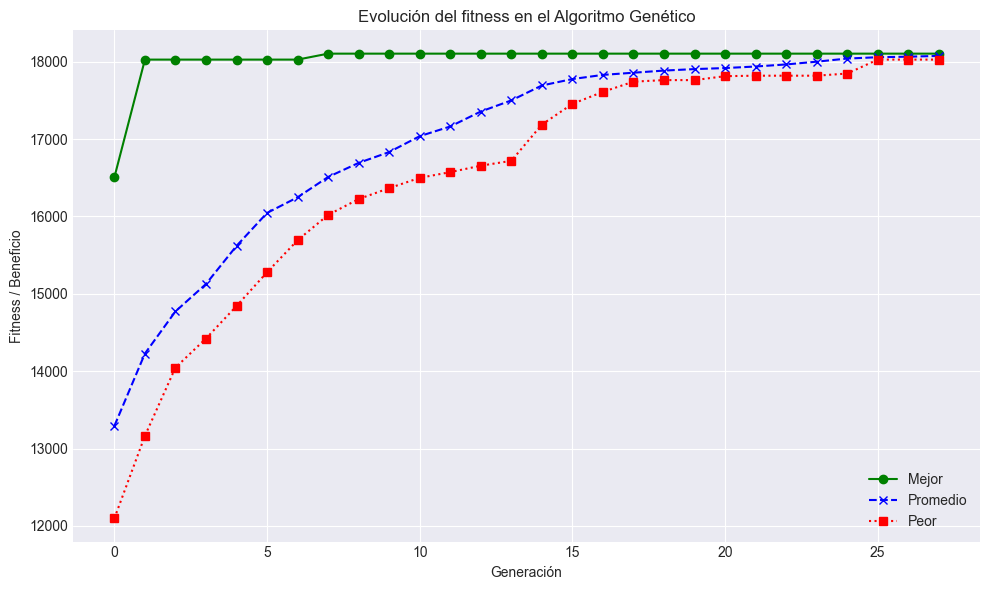

In [17]:
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# GRAFICA HISTORIAL
# -------------------------------------------------------------------
generaciones = [h['generacion'] for h in historial]
mejores = [h['mejor'] for h in historial]
promedios = [h['promedio'] for h in historial]
peores = [h['peor'] for h in historial]

plt.figure(figsize=(10,6))
plt.plot(generaciones, mejores, label='Mejor', color='green', marker='o')
plt.plot(generaciones, promedios, label='Promedio', color='blue', linestyle='--', marker='x')
plt.plot(generaciones, peores, label='Peor', color='red', linestyle=':', marker='s')

plt.xlabel('Generación')
plt.ylabel('Fitness / Beneficio')
plt.title('Evolución del fitness en el Algoritmo Genético')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Solo factibilidad permitida

Gen 0: Mejor=16256, Promedio=14841.65, Peor=14048, Tiempo=0.023s
Gen 1: Mejor=16578, Promedio=15381.35, Peor=14624, Tiempo=0.023s
Gen 2: Mejor=17454, Promedio=15780.47, Peor=15375, Tiempo=0.023s
Gen 3: Mejor=17454, Promedio=15930.82, Peor=15582, Tiempo=0.023s
Gen 4: Mejor=17818, Promedio=16211.31, Peor=15793, Tiempo=0.023s
Gen 5: Mejor=17818, Promedio=16417.21, Peor=16050, Tiempo=0.023s
Gen 6: Mejor=17818, Promedio=16561.65, Peor=16228, Tiempo=0.023s
Gen 7: Mejor=18026, Promedio=16705.53, Peor=16320, Tiempo=0.023s
Gen 8: Mejor=18026, Promedio=16814.68, Peor=16449, Tiempo=0.023s
Gen 9: Mejor=18026, Promedio=16929.62, Peor=16581, Tiempo=0.023s
Gen 10: Mejor=18026, Promedio=17003.44, Peor=16661, Tiempo=0.023s
Gen 11: Mejor=18026, Promedio=17115.00, Peor=16712, Tiempo=0.023s
Gen 12: Mejor=18026, Promedio=17190.25, Peor=16718, Tiempo=0.023s
Gen 13: Mejor=18026, Promedio=17237.30, Peor=16748, Tiempo=0.023s
Gen 14: Mejor=18026, Promedio=17386.31, Peor=16818, Tiempo=0.023s
Gen 15: Mejor=18026,

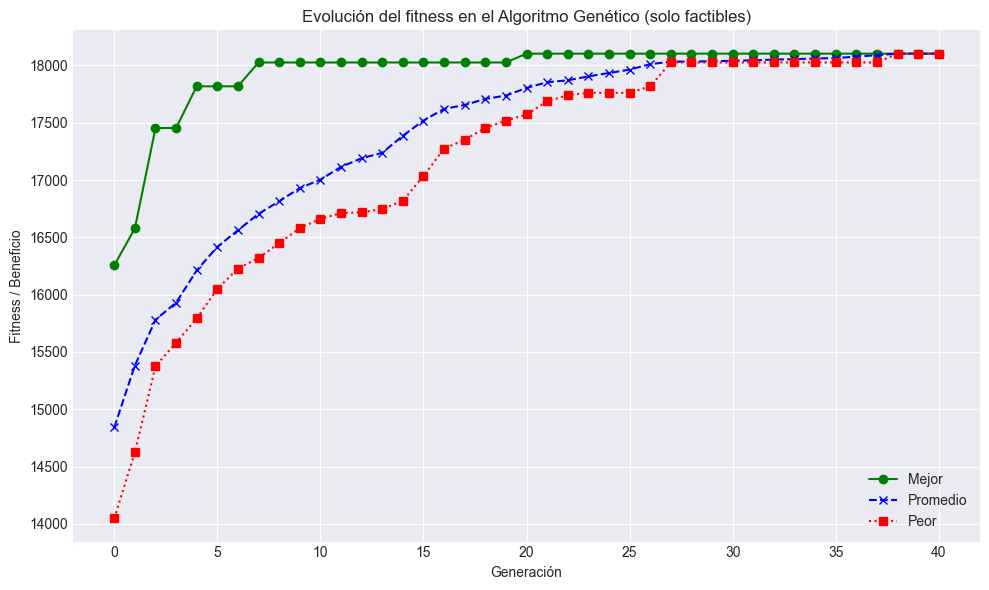

In [18]:
import random
import time
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# PROBLEMA DE LA MOCHILA
# -------------------------------------------------------------------
pesos = [61, 58, 92, 50, 108, 83, 93, 101, 54, 50, 72, 51, 100, 108, 91, 112, 66, 58, 110, 73]
beneficios = [1100, 1147, 1442, 1591, 1078, 1385, 1777, 1196, 1753, 1371, 1517, 1675 , 1193, 1177, 1365, 1143, 1314, 1526, 1470, 1605]
capacidad = 800

N = len(pesos)

# -------------------------------------------------------------------
# PARÁMETROS GA
# -------------------------------------------------------------------
TAM_POB = 100
GENERACIONES = 50
PROB_CRUZA = 0.9
PROB_MUT = 0.1
MAX_ESTANCAMIENTO = 20

# -------------------------------------------------------------------
# FUNCIONES
# -------------------------------------------------------------------
def crear_individuo_factible():
    """Crea un individuo factible respetando la capacidad."""
    ind = [0] * N
    peso_acum = 0
    indices = list(range(N))
    random.shuffle(indices)
    
    for i in indices:
        if peso_acum + pesos[i] <= capacidad:
            ind[i] = 1
            peso_acum += pesos[i]
    return ind

def evaluar(ind):
    return sum(v * x for v, x in zip(beneficios, ind))

def ruleta(poblacion):
    """Selección por ruleta entre individuos factibles."""
    fitness = [evaluar(ind) for ind in poblacion]
    total_fitness = sum(fitness)
    if total_fitness == 0:
        return random.choice(poblacion)
    r = random.uniform(0, total_fitness)
    acumulado = 0
    for ind, fit in zip(poblacion, fitness):
        acumulado += fit
        if acumulado >= r:
            return ind

def cruza(a, b):
    """Cruza de un punto asegurando factibilidad."""
    if random.random() > PROB_CRUZA:
        return a[:], b[:]
    
    punto = random.randint(1, N-1)
    h1 = a[:punto] + b[punto:]
    h2 = b[:punto] + a[punto:]
    
    return reparar_individuo(h1), reparar_individuo(h2)

def mutar(ind):
    """Mutación bit-flip asegurando factibilidad."""
    for i in range(N):
        if random.random() < PROB_MUT:
            ind[i] = 1 - ind[i]
    return reparar_individuo(ind)

def reparar_individuo(ind):
    """Repara un individuo para que sea factible."""
    peso_total = sum(w * x for w, x in zip(pesos, ind))
    if peso_total <= capacidad:
        return ind
    # Si excede, desactivar algunos items aleatoriamente hasta que sea factible
    indices = [i for i, x in enumerate(ind) if x == 1]
    random.shuffle(indices)
    while peso_total > capacidad and indices:
        i = indices.pop()
        ind[i] = 0
        peso_total -= pesos[i]
    return ind

# -------------------------------------------------------------------
# ALGORITMO GENÉTICO
# -------------------------------------------------------------------
poblacion = [crear_individuo_factible() for _ in range(TAM_POB)]

historial = []
pasos_total = 0
inicio_total = time.time()
mejor_global = 0
contador_estancamiento = 0

for gen in range(GENERACIONES):
    gen_inicio = time.time()
    
    for _ in range(TAM_POB):
        padre = ruleta(poblacion)
        madre = ruleta(poblacion)
        hijo1, hijo2 = cruza(padre, madre)
        hijo1 = mutar(hijo1)
        hijo2 = mutar(hijo2)

        fit_h1 = evaluar(hijo1)
        fit_h2 = evaluar(hijo2)

        poblacion_con_fit = [(ind, evaluar(ind)) for ind in poblacion]
        peores = sorted(poblacion_con_fit, key=lambda x: x[1])[:2]
        (peor1, fit_p1), (peor2, fit_p2) = peores
        hijos = sorted([(hijo1, fit_h1), (hijo2, fit_h2)], key=lambda x: x[1], reverse=True)

        if hijos[0][1] > fit_p1:
            poblacion.remove(peor1)
            poblacion.append(hijos[0][0])
        if hijos[1][1] > fit_p2:
            poblacion.remove(peor2)
            poblacion.append(hijos[1][0])
        
        pasos_total += 1

    # Estadísticas
    fitness_gen = [evaluar(ind) for ind in poblacion]
    mejor_fit = max(fitness_gen)
    peor_fit = min(fitness_gen)
    promedio_fit = sum(fitness_gen) / len(fitness_gen)
    tiempo_gen = time.time() - gen_inicio

    historial.append({
        'generacion': gen,
        'mejor': mejor_fit,
        'promedio': promedio_fit,
        'peor': peor_fit,
        'tiempo': tiempo_gen
    })

    print(f"Gen {gen}: Mejor={mejor_fit}, Promedio={promedio_fit:.2f}, Peor={peor_fit}, Tiempo={tiempo_gen:.3f}s")

    # Verificar estancamiento
    if mejor_fit > mejor_global:
        mejor_global = mejor_fit
        contador_estancamiento = 0
    else:
        contador_estancamiento += 1
    if contador_estancamiento >= MAX_ESTANCAMIENTO:
        print(f"\nNo hubo mejora en {MAX_ESTANCAMIENTO} generaciones, deteniendo algoritmo.")
        break

# -------------------------------------------------------------------
# SOLUCIÓN FINAL
# -------------------------------------------------------------------
mejor = max(poblacion, key=evaluar)
peso_final = sum(w * x for w, x in zip(pesos, mejor))
beneficio_final = evaluar(mejor)
tiempo_total = time.time() - inicio_total

print("\nMejor solución encontrada:")
print("Seleccion:", mejor)
print("Peso total:", peso_final)
print("Beneficio total:", beneficio_final)
print("Tiempo total de cómputo:", tiempo_total, "segundos")
print("Total de pasos (iteraciones):", pasos_total)

# -------------------------------------------------------------------
# GRAFICA HISTORIAL
# -------------------------------------------------------------------
generaciones = [h['generacion'] for h in historial]
mejores = [h['mejor'] for h in historial]
promedios = [h['promedio'] for h in historial]
peores = [h['peor'] for h in historial]

plt.figure(figsize=(10,6))
plt.plot(generaciones, mejores, label='Mejor', color='green', marker='o')
plt.plot(generaciones, promedios, label='Promedio', color='blue', linestyle='--', marker='x')
plt.plot(generaciones, peores, label='Peor', color='red', linestyle=':', marker='s')

plt.xlabel('Generación')
plt.ylabel('Fitness / Beneficio')
plt.title('Evolución del fitness en el Algoritmo Genético (solo factibles)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()